# Libraries

In [ ]:
pip install pandas yfinance ta arch scikit-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.3/985.3 kB 16.0 MB/s eta 0:00:00
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=d9e09dd2266c586bd057ccc2b624ed26b1897f6b6563e63416e08ca780d46c4c
  Stored in directory: /root/.cache/pip/wheels/a1/d7/29/7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta


In [ ]:
pip install hmm hmmlearn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.9/165.9 kB 3.3 MB/s eta 0:00:00
  Created wheel for hmm: filename=hmm-0.0.1-py3-none-any.whl size=1833 sha256=504105921b4ae4429d6ea64c19bc87ed02589dc71b5b52331b44600261c1022b
  Stored in directory: /root/.cache/pip/wheels/88/b0/3a/71d77bb88d69c1b185d157d1a4f7b0df0eb4c1bd98191d449d
Successfully built hmm


# Data

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from ta.volatility import AverageTrueRange
from ta.momentum import RSIIndicator
from arch import arch_model

# -----------------------------------
# STEP 1: Load price & VIX data
# -----------------------------------

# Example: S&P 500 and VIX
df_price = yf.download("^GSPC", start="2015-01-01")  # S&P 500
df_vix = yf.download("^VIX", start="2015-01-01")     # Implied VIX

# Keep necessary columns and align
df = df_price[['Close', 'High', 'Low']].copy()
df['VIX'] = df_vix['Close']

# Drop missing VIX values (e.g., holidays)
df.dropna(inplace=True)

# -----------------------------------
# STEP 2: Compute daily returns
# -----------------------------------
df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
df['return'] = df['Close'].pct_change()

# -----------------------------------
# STEP 3: GARCH(1,1) volatility
# -----------------------------------
returns = df['log_return'].dropna() * 100  # scale for arch model
model = arch_model(returns, vol='GARCH', p=1, q=1)
res = model.fit(disp="off")
df.loc[returns.index, 'garch_vol'] = res.conditional_volatility


# -----------------------------------
# STEP 5: RSI (Momentum feature)
# -----------------------------------
rsi = RSIIndicator(close=df['Close'].squeeze(), window=14)
df['RSI'] = rsi.rsi()

# -----------------------------------
# STEP 6: Lagged returns
# -----------------------------------
for i in range(1, 6):  # 5 lagged returns
    df[f'return_lag_{i}'] = df['return'].shift(i)

# -----------------------------------
# STEP 7: Target — 5-day realized volatility (rolling std dev of returns)
# -----------------------------------
df['realized_vol_5d'] = df['return'].rolling(window=5).std()

df.dropna(inplace=True)


# -----------------------------------
# STEP 8: Final cleanup
# -----------------------------------
df.dropna(inplace=True)

# -----------------------------------
# Final feature matrix & target
# -----------------------------------
features = ['return'] + [f'return_lag_{i}' for i in range(1, 6)] + [
    'garch_vol', 'VIX', 'RSI'
]
target = ['realized_vol_5d']

main = df[features+target]
X = df[features]
y = df[target]

print(X.head())
print(y.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Price         return return_lag_1 return_lag_2 return_lag_3 return_lag_4  \
Ticker                                                                     
Date                                                                       
2015-01-22  0.015270     0.004732     0.001550     0.013424    -0.009248   
2015-01-23 -0.005492     0.015270     0.004732     0.001550     0.013424   
2015-01-26  0.002568    -0.005492     0.015270     0.004732     0.001550   
2015-01-27 -0.013388     0.002568    -0.005492     0.015270     0.004732   
2015-01-28 -0.013496    -0.013388     0.002568    -0.005492     0.015270   

Price      return_lag_5 garch_vol        VIX        RSI  
Ticker                                                   
Date                                                     
2015-01-22    -0.005813  0.901888  16.400000  57.904317  
2015-01-23    -0.009248  1.024673  16.660000  53.845710  
2015-01-26     0.013424  0.970794  15.520000  55.411252  
2015-01-27     0.001550  0.889830  17.21999

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2645 entries, 2015-01-22 to 2025-07-29
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (return, )        2645 non-null   float64
 1   (return_lag_1, )  2645 non-null   float64
 2   (return_lag_2, )  2645 non-null   float64
 3   (return_lag_3, )  2645 non-null   float64
 4   (return_lag_4, )  2645 non-null   float64
 5   (return_lag_5, )  2645 non-null   float64
 6   (garch_vol, )     2645 non-null   float64
 7   (VIX, )           2645 non-null   float64
 8   (RSI, )           2645 non-null   float64
 9   (regime, )        2645 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 227.3 KB


In [ ]:
X.isnull().sum()

,,0
Price,Ticker,
return,,0
return_lag_1,,0
return_lag_2,,0
return_lag_3,,0
return_lag_4,,0
return_lag_5,,0
garch_vol,,0
VIX,,0
RSI,,0


In [ ]:
X.describe()

Price,return,return_lag_1,return_lag_2,return_lag_3,return_lag_4,return_lag_5,garch_vol,VIX,RSI
Ticker,,,,,,,,,
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,0.000495,0.000496,0.000496,0.000502,0.000496,0.000493,0.983866,18.386697,55.573572
std,0.011431,0.011431,0.011431,0.011434,0.011435,0.011436,0.596513,7.272456,11.408941
min,-0.119841,-0.119841,-0.119841,-0.119841,-0.119841,-0.119841,0.443231,9.140000,16.766413
25%,-0.003781,-0.003781,-0.003781,-0.003781,-0.003789,-0.003799,0.643815,13.447500,47.424279
50%,0.000691,0.000698,0.000698,0.000703,0.000698,0.000691,0.821600,16.520000,57.059201
75%,0.005804,0.005804,0.005804,0.005809,0.005809,0.005809,1.139025,21.405000,63.987569
max,0.095154,0.095154,0.095154,0.095154,0.095154,0.095154,7.844649,82.690002,86.686650


In [ ]:
X.corr()

,Price,return,return_lag_1,return_lag_2,return_lag_3,return_lag_4,return_lag_5,garch_vol,VIX,RSI
,Ticker,,,,,,,,,
Price,Ticker,,,,,,,,,
return,,1.000000,-0.136289,0.081343,-0.034629,-0.069792,0.043143,0.008747,-0.159469,0.296809
return_lag_1,,-0.136289,1.000000,-0.136273,0.081480,-0.034746,-0.069866,-0.050241,-0.115973,0.258300
return_lag_2,,0.081343,-0.136273,1.000000,-0.136199,0.081429,-0.034770,-0.070568,-0.121165,0.243758
return_lag_3,,-0.034629,0.081480,-0.136199,1.000000,-0.136508,0.081174,-0.096159,-0.118962,0.218624
return_lag_4,,-0.069792,-0.034746,0.081429,-0.136508,1.000000,-0.136348,-0.110775,-0.104113,0.189182
return_lag_5,,0.043143,-0.069866,-0.034770,0.081174,-0.136348,1.000000,-0.131553,-0.108149,0.173824
garch_vol,,0.008747,-0.050241,-0.070568,-0.096159,-0.110775,-0.131553,1.000000,0.851026,-0.464105
VIX,,-0.159469,-0.115973,-0.121165,-0.118962,-0.104113,-0.108149,0.851026,1.000000,-0.535835


In [ ]:
main.corr()

,Price,return,return_lag_1,return_lag_2,return_lag_3,return_lag_4,return_lag_5,garch_vol,VIX,RSI,realized_vol_5d
,Ticker,,,,,,,,,,
Price,Ticker,,,,,,,,,,
return,,1.000000,-0.136289,0.081343,-0.034629,-0.069792,0.043143,0.008747,-0.159469,0.296809,-0.005090
return_lag_1,,-0.136289,1.000000,-0.136273,0.081480,-0.034746,-0.069866,-0.050241,-0.115973,0.258300,-0.050670
return_lag_2,,0.081343,-0.136273,1.000000,-0.136199,0.081429,-0.034770,-0.070568,-0.121165,0.243758,-0.094295
return_lag_3,,-0.034629,0.081480,-0.136199,1.000000,-0.136508,0.081174,-0.096159,-0.118962,0.218624,-0.127420
return_lag_4,,-0.069792,-0.034746,0.081429,-0.136508,1.000000,-0.136348,-0.110775,-0.104113,0.189182,-0.174303
return_lag_5,,0.043143,-0.069866,-0.034770,0.081174,-0.136348,1.000000,-0.131553,-0.108149,0.173824,-0.168826
garch_vol,,0.008747,-0.050241,-0.070568,-0.096159,-0.110775,-0.131553,1.000000,0.851026,-0.464105,0.923432
VIX,,-0.159469,-0.115973,-0.121165,-0.118962,-0.104113,-0.108149,0.851026,1.000000,-0.535835,0.808076


#Investor Sentiment

# XGB

In [ ]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [ ]:
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

## Eval

test

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Squared Error: {mse:.6f}")
print(f"Mean Absolute Error: {mae:.6f}")
print("R² Score:", r2)

Mean Squared Error: 0.000007
Mean Absolute Error: 0.001511
R² Score: 0.8160669803619385


train

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score

y_pred = model.predict(X_train)

r2 = r2_score(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
mae = mean_absolute_error(y_train, y_pred)

print(f"Mean Squared Error: {mse:.6f}")
print(f"Mean Absolute Error: {mae:.6f}")
print("R² Score:", r2)

Mean Squared Error: 0.000003
Mean Absolute Error: 0.001319
R² Score: 0.9484096765518188


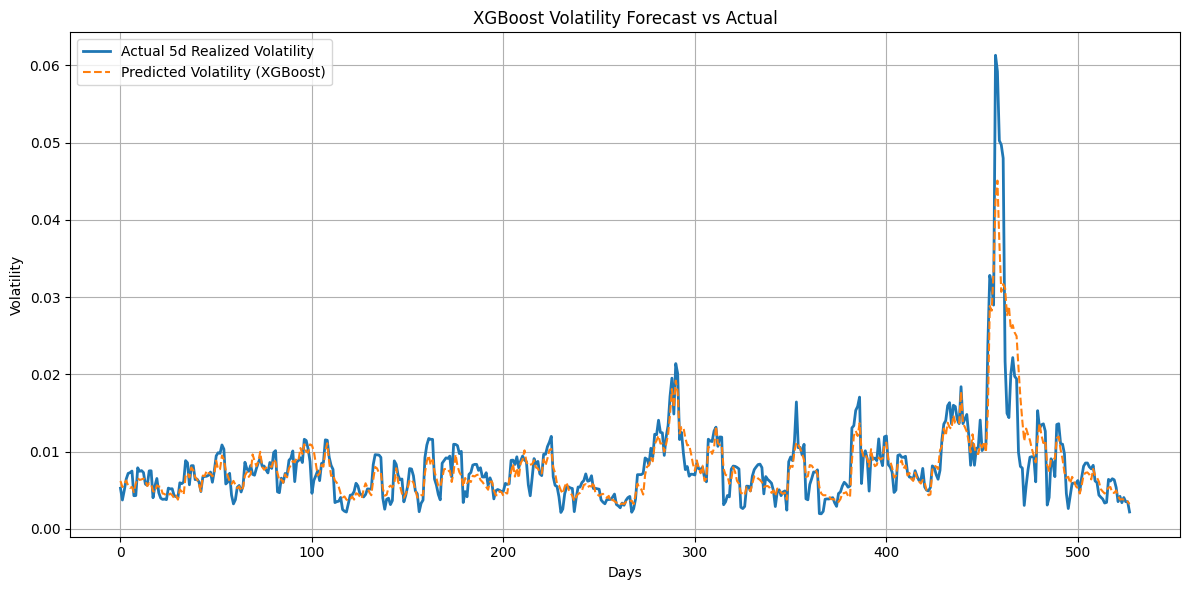

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual 5d Realized Volatility', linewidth=2)
plt.plot(y_pred, label='Predicted Volatility (XGBoost)', linestyle='--')
plt.title('XGBoost Volatility Forecast vs Actual')
plt.xlabel('Days')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


TypeError: unhashable type: 'numpy.ndarray'

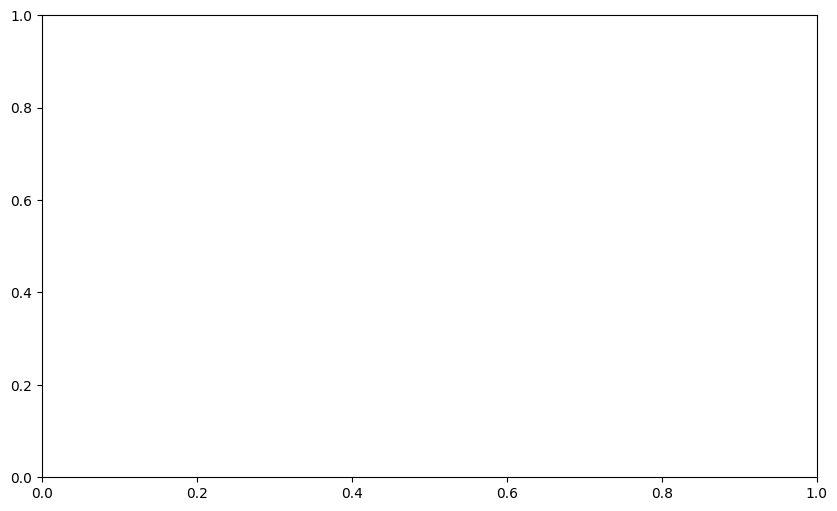

In [ ]:
importances = model.feature_importances_
feature_names = list(X.columns)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.xlabel("Importance")
plt.title("Feature Importance - XGBoost")
plt.grid(True)
plt.tight_layout()
plt.show()


# LSTM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# -------------------------------
# Step 1: Feature Matrix and Target
# -------------------------------
X = df[features].values
y = df['realized_vol_5d'].values.reshape(-1, 1)

# -------------------------------
# Step 2: Scale the Data
# -------------------------------
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# -------------------------------
# Step 3: Create Sequences for LSTM
# -------------------------------
def create_sequences(X, y, window=10):
    X_seq, y_seq = [], []
    for i in range(window, len(X)):
        X_seq.append(X[i - window:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

seq_len = 1  # 1-day window
X_seq, y_seq = create_sequences(X_scaled, y_scaled, window=seq_len)

# -------------------------------
# Step 4: Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False)

# -------------------------------
# Step 5: Define and Train LSTM
# -------------------------------
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.fit(X_train, y_train, validation_split=0.1, epochs=100, batch_size=32, callbacks=[early_stop], verbose=0)

# -------------------------------
# Step 6: Predict and Inverse Scale
# -------------------------------
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

# -------------------------------
# Step 7: Calculate R²
# -------------------------------
r2 = r2_score(y_test_actual, y_pred)
print("R² Score (LSTM):", r2)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
R² Score (LSTM): 0.6906006725137852


In [ ]:
# --- New imports ---
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# -------------------------------
# Utility: sequence builder for LSTM
# -------------------------------
def create_sequences(X, y, window=1):
    X_seq, y_seq = [], []
    for i in range(window, len(X)):
        X_seq.append(X[i - window:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

# -------------------------------
# Utility: build and train a simple LSTM for a given train/test split
# -------------------------------
def train_and_predict_lstm(X_train, y_train, X_test, seq_len=1, epochs=100, batch_size=32, patience=5, verbose=0):
    model = Sequential([
        LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    early = EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True)
    model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early],
        verbose=verbose
    )
    y_pred = model.predict(X_test, verbose=0)
    return y_pred

# -------------------------------
# HMM fit on training window and transform both train/test with regime probabilities
# -------------------------------
def fit_hmm_and_transform(train_df, test_df, hmm_features, n_states=2):
    # Fill small gaps to avoid NaNs
    trX = train_df[hmm_features].copy()
    teX = test_df[hmm_features].copy()
    trX = trX.fillna(method="ffill").fillna(method="bfill")
    teX = teX.fillna(method="ffill").fillna(method="bfill")

    sc = StandardScaler()
    trXs = sc.fit_transform(trX.values)
    teXs = sc.transform(teX.values)

    hmm = GaussianHMM(
        n_components=n_states,
        covariance_type='full',
        n_iter=500,
        random_state=42
    )
    hmm.fit(trXs)

    # get posterior probabilities (regime responsibilities)
    trP = hmm.predict_proba(trXs)  # shape: (n_train, n_states)
    teP = hmm.predict_proba(teXs)  # shape: (n_test, n_states)

    # Return as DataFrames aligned to indices
    trP_df = pd.DataFrame(trP, index=trX.index, columns=[f"regime_{k}" for k in range(n_states)])
    teP_df = pd.DataFrame(teP, index=teX.index, columns=[f"regime_{k}" for k in range(n_states)])
    return trP_df, teP_df

# -------------------------------
# Rolling-window backtest
# -------------------------------
def rolling_backtest_lstm(
    df,
    base_features,
    target_col='realized_vol_5d',
    seq_len=1,
    window=756,        # ~3Y of trading days as training window
    step=20,           # predict 1 trading month forward each iteration
    use_hmm=False,
    hmm_features=None,
    n_states=2,
    epochs=100,
    batch_size=32,
    patience=5,
    verbose=0
):
    """
    Returns concatenated predictions & metrics for the rolling backtest.
    """
    assert target_col in df.columns
    if use_hmm:
        assert hmm_features is not None and all(h in df.columns for h in hmm_features)

    preds = []
    actuals = []
    idxs = []

    i = window
    n = len(df)

    while i + step <= n:
        train_idx = slice(i - window, i)
        test_idx  = slice(i, i + step)

        train_df = df.iloc[train_idx].copy()
        test_df  = df.iloc[test_idx].copy()

        # Optionally augment with HMM regime probabilities (fit on training window only)
        if use_hmm:
            trP_df, teP_df = fit_hmm_and_transform(train_df, test_df, hmm_features, n_states=n_states)
            train_df = pd.concat([train_df, trP_df], axis=1)
            test_df  = pd.concat([test_df,  teP_df], axis=1)

        # Build final feature list for this run
        run_features = base_features.copy()
        if use_hmm:
            run_features += [f"regime_{k}" for k in range(n_states)]

        # Scale features & target using training window only
        X_tr = train_df[run_features].values
        y_tr = train_df[[target_col]].values

        X_te = test_df[run_features].values
        y_te = test_df[[target_col]].values

        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler()
        X_tr_s = scaler_X.fit_transform(X_tr)
        y_tr_s = scaler_y.fit_transform(y_tr)
        X_te_s = scaler_X.transform(X_te)
        y_te_s = scaler_y.transform(y_te)

        # Sequence-ify
        X_tr_seq, y_tr_seq = create_sequences(X_tr_s, y_tr_s, window=seq_len)
        X_te_seq, y_te_seq = create_sequences(X_te_s, y_te_s, window=seq_len)

        # If test chunk is too small for seq_len, skip
        if len(X_te_seq) == 0:
            i += step
            continue

        # Train and predict
        y_pred_s = train_and_predict_lstm(
            X_tr_seq, y_tr_seq, X_te_seq,
            seq_len=seq_len, epochs=epochs, batch_size=batch_size, patience=patience, verbose=verbose
        )
        # Inverse-scale predictions and align indices (drop first seq_len rows)
        y_pred = scaler_y.inverse_transform(y_pred_s)
        y_true = scaler_y.inverse_transform(y_te_seq)

        # Collect
        # Align with test_df index starting at seq_len offset
        use_index = test_df.index[seq_len:]
        preds.append(pd.Series(y_pred.ravel(), index=use_index))
        actuals.append(pd.Series(y_true.ravel(), index=use_index))
        idxs.append(use_index)

        i += step

    if len(preds) == 0:
        raise ValueError("Backtest produced no predictions. Consider reducing seq_len or step/window sizes.")

    y_pred_all = pd.concat(preds).sort_index()
    y_true_all = pd.concat(actuals).sort_index()

    # Metrics
    # R^2
    r2 = r2_score(y_true_all.values, y_pred_all.values)
    # MAPE with epsilon to avoid blow-ups near zero
    eps = 1e-8
    denom = np.maximum(eps, np.abs(y_true_all.values))
    mape = np.mean(np.abs((y_true_all.values - y_pred_all.values) / denom)) * 100.0

    results = pd.DataFrame({
        "y_true": y_true_all,
        "y_pred": y_pred_all
    })
    return results, r2, mape

# -------------------------------
# Run two backtests: baseline vs HMM-augmented
# -------------------------------

# Your existing feature list from above:
# features = ['return'] + [f'return_lag_{i}' for i in range(1, 6)] + ['garch_vol', 'VIX', 'RSI']
# target = ['realized_vol_5d']
target_col = 'realized_vol_5d'

# Choose which columns HMM should see to infer regimes (you can tweak)
hmm_features = ['return', 'garch_vol', 'VIX']

# Backtest settings (tweakable)
SEQ_LEN = 1      # keep your original 1-day window, can try 5/10 for more memory
WINDOW  = 756    # ~3 years of trading days
STEP    = 20     # predict one month ahead each roll
EPOCHS  = 60     # reduce a bit for speed; increase for accuracy if you like
BATCH   = 64
PATIENCE= 6
VERBOSE = 0

# Baseline (no HMM regimes)
baseline_results, baseline_r2, baseline_mape = rolling_backtest_lstm(
    df=df,
    base_features=features,
    target_col=target_col,
    seq_len=SEQ_LEN,
    window=WINDOW,
    step=STEP,
    use_hmm=False,
    epochs=EPOCHS,
    batch_size=BATCH,
    patience=PATIENCE,
    verbose=VERBOSE
)

# Regime-augmented (Gaussian HMM)
hmm_results, hmm_r2, hmm_mape = rolling_backtest_lstm(
    df=df,
    base_features=features,
    target_col=target_col,
    seq_len=SEQ_LEN,
    window=WINDOW,
    step=STEP,
    use_hmm=True,
    hmm_features=hmm_features,
    n_states=2,           # try 2–4 and compare
    epochs=EPOCHS,
    batch_size=BATCH,
    patience=PATIENCE,
    verbose=VERBOSE
)

# Report improvements
delta_r2  = hmm_r2 - baseline_r2
delta_mape= baseline_mape - hmm_mape  # positive means MAPE improved (got smaller)

print(f"Baseline:   R²={baseline_r2:.4f}, MAPE={baseline_mape:.2f}%")
print(f"HMM Regime: R²={hmm_r2:.4f}, MAPE={hmm_mape:.2f}%")
print(f"ΔR² (HMM - Base): {delta_r2:.4f}")
print(f"ΔMAPE (Base - HMM): {delta_mape:.2f} percentage points")

# Optional: join for inspection
joined = baseline_results.join(hmm_results[['y_pred']].rename(columns={'y_pred':'y_pred_hmm'}), how='inner')
print(joined.tail())


KeyError: "['return', 'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_4', 'return_lag_5', 'garch_vol', 'VIX', 'RSI'] not in index"

# ARIMA

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(y_train, order=(1, 0, 0))
arima_result = arima_model.fit()

# Forecast for test length
arima_forecast = arima_result.forecast(steps=len(y_test))

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# XGBoost prediction already computed as: y_pred
# Align XGBoost and ARIMA targets
y_test_xgb = y_test[-len(y_pred):]
arima_forecast = arima_forecast[-len(y_pred):]

# Metrics
print("🔹 XGBoost")
print("r2",r2_score(y_test_xgb, y_pred))
print("  MSE:", mean_squared_error(y_test_xgb, y_pred))
print("  MAE:", mean_absolute_error(y_test_xgb, y_pred))

print("\n🔹 ARIMA")
print("r2",r2_score(arima_forecast,y_pred))
print("  MSE:", mean_squared_error(y_test_xgb, arima_forecast))
print("  MAE:", mean_absolute_error(y_test_xgb, arima_forecast))


🔹 XGBoost
r2 0.8156330585479736
  MSE: 6.629110885114642e-06
  MAE: 0.0015121160540729761

🔹 ARIMA
r2 -298.4675295451298
  MSE: 3.673557083187443e-05
  MAE: 0.003655171050171805


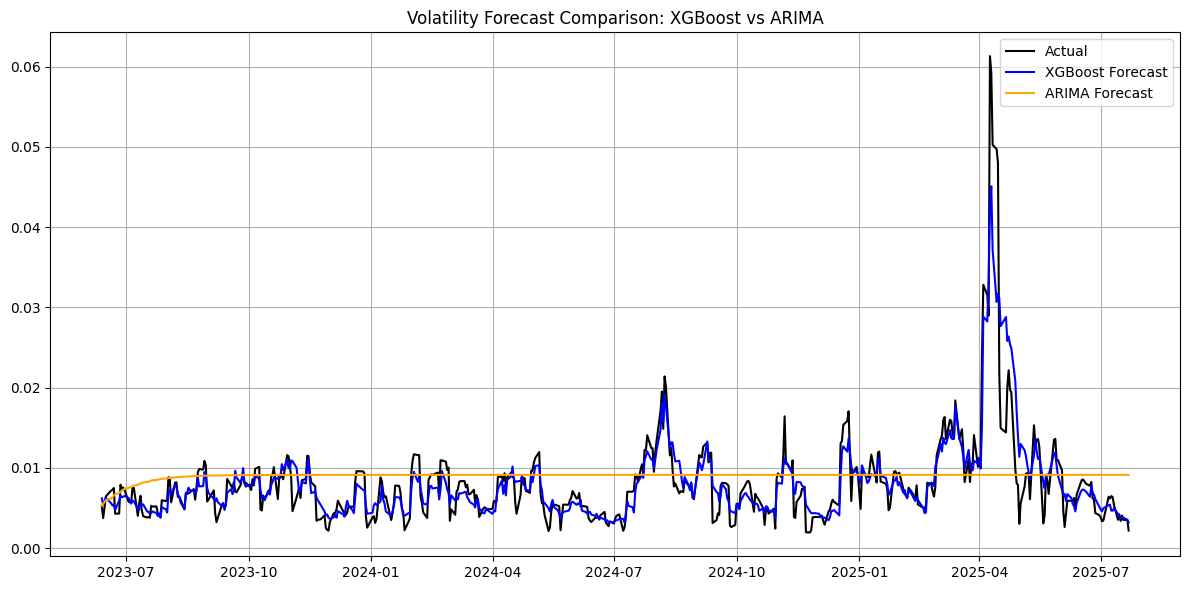

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_xgb.index, y_test_xgb, label='Actual', color='black')
plt.plot(y_test_xgb.index, y_pred, label='XGBoost Forecast', color='blue')
plt.plot(y_test_xgb.index, arima_forecast, label='ARIMA Forecast', color='orange')
plt.title('Volatility Forecast Comparison: XGBoost vs ARIMA')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
